### First, I imported the dataset using pandas to begin the analysis. This allows me to work with structured tabular data efficiently

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing   import PolynomialFeatures
from sklearn.linear_model    import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics         import r2_score, mean_squared_error

In [71]:
df = pd.read_csv("speed_fuel_dataset.csv")

### I checked the structure of the dataset, including number of rows and columns, data types, and sample records to understand the data before processing

In [74]:
df.shape

(200, 2)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   speed_kmh        200 non-null    float64
 1   fuel_efficiency  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


### I verified that there are no missing values or duplicate records to ensure data quality and avoid incorrect model predictions.

In [79]:
df.duplicated().sum()

0

In [81]:
df.rename(columns = {'speed_kmh' : 'Speed','fuel_efficiency' : 'Fuel_efficiency'},inplace =True)     

In [83]:
df

,Speed,Fuel_efficiency
0,58.69,20.023
1,133.59,0.594
2,105.16,13.580
3,87.83,17.488
4,30.28,17.966
...,...,...
195,55.40,19.297
196,104.37,13.036
197,126.62,4.007
198,125.32,5.088


### I used a scatter plot to understand the relationship between speed and fuel efficiency. The pattern appeared non-linear, indicating that a simple linear model may not be sufficient

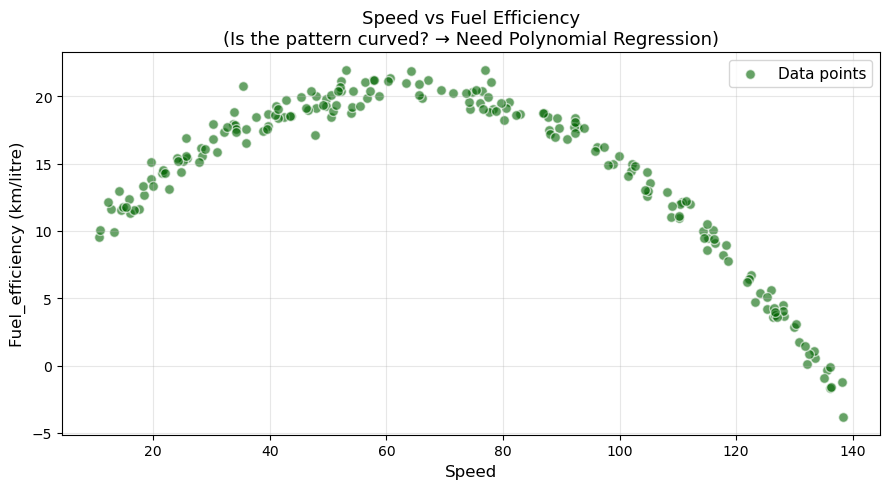

In [86]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df['Speed'],
    df['Fuel_efficiency'],
    alpha=0.6,                # transparency
    color='darkgreen',
    edgecolors='white',
    s=50,                     # dot size
    label='Data points'
)

plt.xlabel('Speed',       fontsize=12)
plt.ylabel('Fuel_efficiency (km/litre)', fontsize=12)
plt.title('Speed vs Fuel Efficiency\n(Is the pattern curved? → Need Polynomial Regression)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### I used a boxplot to check for outliers in the data, as extreme values can negatively impact model performance

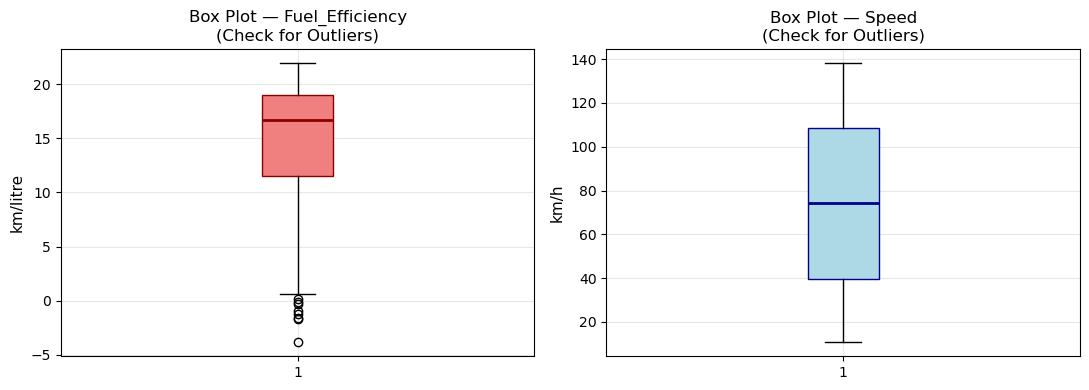

Outliers in Fuel_efficiency : 8
Outliers in Speed       : 0

✅ No significant outliers — data looks clean!


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(df['Fuel_efficiency'], patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='darkred'),
                medianprops=dict(color='darkred', linewidth=2))
axes[0].set_title('Box Plot — Fuel_Efficiency\n(Check for Outliers)', fontsize=12)
axes[0].set_ylabel('km/litre', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['Speed'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='darkblue'),
                medianprops=dict(color='darkblue', linewidth=2))
axes[1].set_title('Box Plot — Speed\n(Check for Outliers)', fontsize=12)
axes[1].set_ylabel('km/h', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count outliers using IQR method
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

print(f'Outliers in Fuel_efficiency : {count_outliers(df["Fuel_efficiency"])}')
print(f'Outliers in Speed       : {count_outliers(df["Speed"])}')
print()
print('✅ No significant outliers — data looks clean!')

### I split the dataset into training and testing sets to evaluate how well the model generalizes to unseen data

In [92]:
X = df[['Speed']].values
y = df[['Fuel_efficiency']].values

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size    = 0.2,    # 20% for testing
    random_state = 42      # reproducible split
)


### Since the relationship between variables appeared non-linear, I used polynomial features to capture this complexity

In [97]:
degree = 2  # Start with degree 2 — we'll optimise this in Cell 13

poly = PolynomialFeatures(degree=degree, include_bias=False)


# #   include_bias=False → don't add a column of 1s
# #   (LinearRegression already handles the intercept internally)

# # TRAIN: fit and transform
X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

### I trained a Linear Regression model on the transformed polynomial features to learn the relationship between speed and fuel efficiency.

In [100]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

### I generated predictions on both training and test data to evaluate model performance and detect overfitting

In [103]:
y_pred = model.predict(X_test_poly)

In [105]:
X_test

array([[ 74.19],
       [ 33.84],
       [ 88.98],
       [ 40.89],
       [ 10.9 ],
       [123.29],
       [138.3 ],
       [ 98.08],
       [ 93.87],
       [ 96.13],
       [ 28.32],
       [130.21],
       [118.59],
       [ 56.6 ],
       [116.24],
       [ 60.28],
       [ 21.5 ],
       [ 28.84],
       [ 53.02],
       [ 19.69],
       [ 39.63],
       [ 49.55],
       [ 16.69],
       [ 82.97],
       [ 80.55],
       [ 60.53],
       [ 50.43],
       [114.29],
       [ 65.52],
       [ 25.58],
       [102.05],
       [ 66.15],
       [129.84],
       [104.77],
       [128.07],
       [127.98],
       [ 52.02],
       [101.39],
       [ 21.74],
       [110.27]])

In [107]:
y_test

array([[19.555],
       [18.857],
       [16.963],
       [18.583],
       [10.067],
       [ 4.699],
       [-3.849],
       [14.906],
       [17.615],
       [16.225],
       [15.564],
       [ 3.066],
       [ 7.793],
       [19.901],
       [ 9.404],
       [21.108],
       [14.314],
       [16.075],
       [21.98 ],
       [15.146],
       [18.692],
       [19.758],
       [11.568],
       [18.682],
       [19.132],
       [21.373],
       [18.422],
       [ 9.964],
       [20.108],
       [16.88 ],
       [14.998],
       [19.86 ],
       [ 2.895],
       [12.615],
       [ 4.023],
       [ 4.486],
       [20.656],
       [14.076],
       [14.524],
       [10.927]])

In [109]:
y_pred

array([[20.09217483],
       [17.37151558],
       [17.8490576 ],
       [18.77967775],
       [10.05594232],
       [ 5.95184823],
       [-2.19441393],
       [15.60510707],
       [16.72504154],
       [16.14135215],
       [15.99325757],
       [ 2.41864941],
       [ 8.13456322],
       [20.49687016],
       [ 9.16009212],
       [20.61559536],
       [13.95601677],
       [16.1334242 ],
       [20.27810044],
       [13.35327639],
       [18.55699345],
       [19.96885045],
       [12.29692363],
       [18.9702263 ],
       [19.34061971],
       [20.6197571 ],
       [20.05633304],
       [ 9.9777463 ],
       [20.59893179],
       [15.21919562],
       [14.41998363],
       [20.58223448],
       [ 2.61719265],
       [13.5357075 ],
       [ 3.55193031],
       [ 3.5987942 ],
       [20.1987936 ],
       [14.62568687],
       [14.03398326],
       [11.56801363]])

### I used R², MSE, and RMSE to evaluate the model. These metrics help measure accuracy and error in predictions

In [112]:

# ── Model Evaluation ─────────────────────────────────────────────────────────

# Training set metrics (to check for overfitting)
y_train_pred   = model.predict(X_train_poly)
train_r2       = r2_score(y_train, y_train_pred)
train_mse      = mean_squared_error(y_train, y_train_pred)
train_rmse     = np.sqrt(train_mse)

# Test set metrics (true performance)
test_r2        = r2_score(y_test, y_pred)
test_mse       = mean_squared_error(y_test, y_pred)
test_rmse      = np.sqrt(test_mse)

print('=== Model Evaluation Results ===')
print()
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print('-' * 46)
print(f"{'R² (R-squared)':<20} {train_r2:>12.4f} {test_r2:>12.4f}")
print(f"{'MSE':<20} {train_mse:>12.4f} {test_mse:>12.4f}")
print(f"{'RMSE':<20} {train_rmse:>12.4f} {test_rmse:>12.4f}")
print()




=== Model Evaluation Results ===

Metric                      Train         Test
----------------------------------------------
R² (R-squared)             0.9849       0.9818
MSE                        0.5746       0.6861
RMSE                       0.7580       0.8283



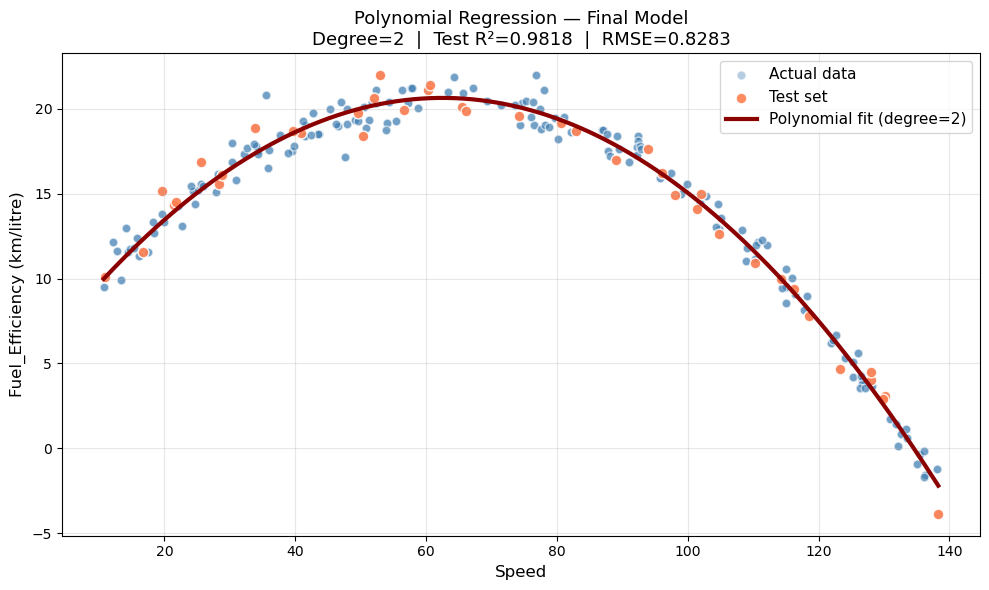

The dark red curve = what the model learned!
It follows the inverted-U shape of the data — as expected for degree 2.
Conclusion:
- There is a non-linear relationship between speed and fuel efficiency
- Polynomial regression fits the data better than linear model
- Model generalizes well (low difference between train & test error)


In [114]:
# ── Final Plot: Fitted Curve ──────────────────────────────────────────────────

# Create smooth X values for plotting the curve
X_smooth = np.linspace(df['Speed'].min(), df['Speed'].max(), 300).reshape(-1, 1)

X_smooth_poly   = poly.transform(X_smooth)
y_smooth_pred   = model.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))

# All data points
plt.scatter(df['Speed'], df['Fuel_efficiency'],
            alpha=0.4, s=40, color='steelblue', edgecolors='white', label='Actual data')

# Train points highlighted
plt.scatter(X_train.ravel(), y_train,
            alpha=0.6, s=40, color='steelblue', edgecolors='white')

# Test points highlighted
plt.scatter(X_test.ravel(), y_test,
            alpha=0.9, s=60, color='coral', edgecolors='white', label='Test set')

# Fitted curve
plt.plot(X_smooth, y_smooth_pred,
         color='darkred', linewidth=3, label=f'Polynomial fit (degree={2})')

plt.xlabel('Speed',               fontsize=12)
plt.ylabel('Fuel_Efficiency (km/litre)', fontsize=12)
plt.title(f'Polynomial Regression — Final Model\n'
          f'Degree={2}  |  Test R²={test_r2:.4f}  |  RMSE={test_rmse:.4f}',
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('The dark red curve = what the model learned!')
print(f'It follows the inverted-U shape of the data — as expected for degree {2}.')
print("Conclusion:")
print("- There is a non-linear relationship between speed and fuel efficiency")
print("- Polynomial regression fits the data better than linear model")
print("- Model generalizes well (low difference between train & test error)")